Splits all wav into 5-second segments with a 2.5-second overlap.
Saves the files in C:\MelodicMind.AI\processed audio.
Ensures short last segments are discarded.
Makes mel spectograms for model training 

Aayat 

In [2]:
import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\aayat.wav"
output_folder = r"C:\MelodicMind.AI\processed_audio"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"aayat_chunk_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")


Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio


In [3]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio"
feature_output_folder = r"C:\MelodicMind.AI\audio_features"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio
    
    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")


Features extracted and saved for C:\MelodicMind.AI\processed_audio\aayat_chunk_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\aayat_chunk_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\aayat_chunk_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\aayat_chunk_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\aayat_chunk_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\aayat_chunk_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\aayat_chunk_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\aayat_chunk_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\aayat_chunk_17.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\aayat_chunk_18.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\aayat_chunk_19.wav
Features extracted and saved for C:\MelodicMind.AI\proc

In [7]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio"
output_folder = r"C:\MelodicMind.AI\audio_features"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Extract features
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")



Feature extraction complete! Data saved in: C:\MelodicMind.AI\audio_features\audio_features.csv


Channa mereya 

In [12]:
import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\Channa Mereya.wav"
output_folder = r"C:\MelodicMind.AI\processed_audio\Channa Mereya chunks"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"channa_chunk_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")


Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio\Channa Mereya chunks


In [13]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio\Channa Mereya chunks"
feature_output_folder = r"C:\MelodicMind.AI\audio_features\Channa Mereya Fea"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio

    # Calculate an appropriate n_fft based on the audio length
    n_fft = 1024  # Default value
    if len(y) < 2048:
        n_fft = 512  # Set n_fft to a smaller value for shorter signals

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")


Features extracted and saved for C:\MelodicMind.AI\processed_audio\Channa Mereya chunks\channa_chunk_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Channa Mereya chunks\channa_chunk_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Channa Mereya chunks\channa_chunk_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Channa Mereya chunks\channa_chunk_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Channa Mereya chunks\channa_chunk_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Channa Mereya chunks\channa_chunk_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Channa Mereya chunks\channa_chunk_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Channa Mereya chunks\channa_chunk_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Channa Mereya chunks\channa_chunk_17.wav
Features extracted and saved 

In [18]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio\Channa Mereya chunks"
output_folder = r"C:\MelodicMind.AI\audio_features\Channa Mereya Fea"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Debugging: Print sample rate and signal length
        print(f"Processing {file}: Sample rate = {sr}, Signal length = {len(y)}")

        # Dynamically set n_fft based on audio length (ensure it's not larger than half the signal length)
        n_fft = min(2048, len(y) // 2)  # Use half the length of the signal as the max n_fft

        # Extract features with adjusted n_fft
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4, n_fft=n_fft)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")


Processing channa_chunk_1.wav: Sample rate = 8000, Signal length = 40000
Processing channa_chunk_10.wav: Sample rate = 8000, Signal length = 40000
Processing channa_chunk_11.wav: Sample rate = 8000, Signal length = 40000
Processing channa_chunk_12.wav: Sample rate = 8000, Signal length = 40000
Processing channa_chunk_13.wav: Sample rate = 8000, Signal length = 40000
Processing channa_chunk_14.wav: Sample rate = 8000, Signal length = 40000
Processing channa_chunk_15.wav: Sample rate = 8000, Signal length = 40000
Processing channa_chunk_16.wav: Sample rate = 8000, Signal length = 40000
Processing channa_chunk_17.wav: Sample rate = 8000, Signal length = 40000
Processing channa_chunk_18.wav: Sample rate = 8000, Signal length = 40000
Processing channa_chunk_19.wav: Sample rate = 8000, Signal length = 40000
Processing channa_chunk_2.wav: Sample rate = 8000, Signal length = 40000
Processing channa_chunk_20.wav: Sample rate = 8000, Signal length = 40000
Processing channa_chunk_21.wav: Sample r

C:\Users\User\PycharmProjects\pythonProject\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1448
  warnings.warn(


DIE WITH A SMILE 

In [19]:
import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\Die With A Smile.wav"
output_folder = r"C:\MelodicMind.AI\processed_audio\Die With A Smile Chunk"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"die_with_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")

Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio\Die With A Smile Chunk


In [21]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio\Die With A Smile Chunk"
feature_output_folder = r"C:\MelodicMind.AI\audio_features\Die With a Smile"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio

    # Calculate an appropriate n_fft based on the audio length
    n_fft = 1024  # Default value
    if len(y) < 2048:
        n_fft = 512  # Set n_fft to a smaller value for shorter signals

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")

Features extracted and saved for C:\MelodicMind.AI\processed_audio\Die With A Smile Chunk\die_with_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Die With A Smile Chunk\die_with_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Die With A Smile Chunk\die_with_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Die With A Smile Chunk\die_with_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Die With A Smile Chunk\die_with_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Die With A Smile Chunk\die_with_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Die With A Smile Chunk\die_with_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Die With A Smile Chunk\die_with_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Die With A Smile Chunk\die_with_17.wav
Features extracted and saved for C:\MelodicMind

In [22]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio\Die With A Smile Chunk"
output_folder = r"C:\MelodicMind.AI\audio_features\Die With a Smile"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Debugging: Print sample rate and signal length
        print(f"Processing {file}: Sample rate = {sr}, Signal length = {len(y)}")

        # Dynamically set n_fft based on audio length (ensure it's not larger than half the signal length)
        n_fft = min(2048, len(y) // 2)  # Use half the length of the signal as the max n_fft

        # Extract features with adjusted n_fft
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4, n_fft=n_fft)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")

Processing die_with_1.wav: Sample rate = 8000, Signal length = 40000
Processing die_with_10.wav: Sample rate = 8000, Signal length = 40000
Processing die_with_11.wav: Sample rate = 8000, Signal length = 40000
Processing die_with_12.wav: Sample rate = 8000, Signal length = 40000
Processing die_with_13.wav: Sample rate = 8000, Signal length = 40000
Processing die_with_14.wav: Sample rate = 8000, Signal length = 40000
Processing die_with_15.wav: Sample rate = 8000, Signal length = 40000
Processing die_with_16.wav: Sample rate = 8000, Signal length = 40000
Processing die_with_17.wav: Sample rate = 8000, Signal length = 40000
Processing die_with_18.wav: Sample rate = 8000, Signal length = 40000
Processing die_with_19.wav: Sample rate = 8000, Signal length = 40000
Processing die_with_2.wav: Sample rate = 8000, Signal length = 40000
Processing die_with_20.wav: Sample rate = 8000, Signal length = 40000
Processing die_with_21.wav: Sample rate = 8000, Signal length = 40000
Processing die_with_22

Kalank Title

In [1]:
import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\Kalank title.wav"
output_folder = r"C:\MelodicMind.AI\processed_audio\Kalank Title Track"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"kalank_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")

Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio\Kalank Title Track


In [2]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio\Kalank Title Track"
feature_output_folder = r"C:\MelodicMind.AI\audio_features\Kalank"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio

    # Calculate an appropriate n_fft based on the audio length
    n_fft = 1024  # Default value
    if len(y) < 2048:
        n_fft = 512  # Set n_fft to a smaller value for shorter signals

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")

Features extracted and saved for C:\MelodicMind.AI\processed_audio\Kalank Title Track\kalank_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Kalank Title Track\kalank_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Kalank Title Track\kalank_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Kalank Title Track\kalank_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Kalank Title Track\kalank_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Kalank Title Track\kalank_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Kalank Title Track\kalank_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Kalank Title Track\kalank_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Kalank Title Track\kalank_17.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Kalank Title Track\kalank_18.wav
F

In [3]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio\Kalank Title Track"
output_folder = r"C:\MelodicMind.AI\audio_features\Kalank"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Debugging: Print sample rate and signal length
        print(f"Processing {file}: Sample rate = {sr}, Signal length = {len(y)}")

        # Dynamically set n_fft based on audio length (ensure it's not larger than half the signal length)
        n_fft = min(2048, len(y) // 2)  # Use half the length of the signal as the max n_fft

        # Extract features with adjusted n_fft
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4, n_fft=n_fft)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")

Processing kalank_1.wav: Sample rate = 8000, Signal length = 40000
Processing kalank_10.wav: Sample rate = 8000, Signal length = 40000
Processing kalank_11.wav: Sample rate = 8000, Signal length = 40000
Processing kalank_12.wav: Sample rate = 8000, Signal length = 40000
Processing kalank_13.wav: Sample rate = 8000, Signal length = 40000
Processing kalank_14.wav: Sample rate = 8000, Signal length = 40000
Processing kalank_15.wav: Sample rate = 8000, Signal length = 40000
Processing kalank_16.wav: Sample rate = 8000, Signal length = 40000
Processing kalank_17.wav: Sample rate = 8000, Signal length = 40000
Processing kalank_18.wav: Sample rate = 8000, Signal length = 40000
Processing kalank_19.wav: Sample rate = 8000, Signal length = 40000
Processing kalank_2.wav: Sample rate = 8000, Signal length = 40000
Processing kalank_20.wav: Sample rate = 8000, Signal length = 40000
Processing kalank_21.wav: Sample rate = 8000, Signal length = 40000
Processing kalank_22.wav: Sample rate = 8000, Sign

Laal Ishq

In [1]:

import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\Laal Ishq.wav"
output_folder = r"C:\MelodicMind.AI\processed_audio\Laal Ishq"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"laal_ishq_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")

Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio\Laal Ishq


In [2]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio\Laal Ishq"
feature_output_folder = r"C:\MelodicMind.AI\audio_features\Laal Ishq"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio

    # Calculate an appropriate n_fft based on the audio length
    n_fft = 1024  # Default value
    if len(y) < 2048:
        n_fft = 512  # Set n_fft to a smaller value for shorter signals

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")

Features extracted and saved for C:\MelodicMind.AI\processed_audio\Laal Ishq\laal_ishq_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Laal Ishq\laal_ishq_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Laal Ishq\laal_ishq_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Laal Ishq\laal_ishq_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Laal Ishq\laal_ishq_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Laal Ishq\laal_ishq_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Laal Ishq\laal_ishq_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Laal Ishq\laal_ishq_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Laal Ishq\laal_ishq_17.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Laal Ishq\laal_ishq_18.wav
Features extracted and saved for C:\MelodicMind.AI\processed_

In [3]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio\Laal Ishq"
output_folder = r"C:\MelodicMind.AI\audio_features\Laal Ishq"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Debugging: Print sample rate and signal length
        print(f"Processing {file}: Sample rate = {sr}, Signal length = {len(y)}")

        # Dynamically set n_fft based on audio length (ensure it's not larger than half the signal length)
        n_fft = min(2048, len(y) // 2)  # Use half the length of the signal as the max n_fft

        # Extract features with adjusted n_fft
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4, n_fft=n_fft)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")

Processing laal_ishq_1.wav: Sample rate = 8000, Signal length = 40000
Processing laal_ishq_10.wav: Sample rate = 8000, Signal length = 40000
Processing laal_ishq_11.wav: Sample rate = 8000, Signal length = 40000
Processing laal_ishq_12.wav: Sample rate = 8000, Signal length = 40000
Processing laal_ishq_13.wav: Sample rate = 8000, Signal length = 40000
Processing laal_ishq_14.wav: Sample rate = 8000, Signal length = 40000
Processing laal_ishq_15.wav: Sample rate = 8000, Signal length = 40000
Processing laal_ishq_16.wav: Sample rate = 8000, Signal length = 40000
Processing laal_ishq_17.wav: Sample rate = 8000, Signal length = 40000
Processing laal_ishq_18.wav: Sample rate = 8000, Signal length = 40000
Processing laal_ishq_19.wav: Sample rate = 8000, Signal length = 40000
Processing laal_ishq_2.wav: Sample rate = 8000, Signal length = 40000
Processing laal_ishq_20.wav: Sample rate = 8000, Signal length = 40000
Processing laal_ishq_21.wav: Sample rate = 8000, Signal length = 40000
Processi

Khamoshiyan 

In [4]:
import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\khamoshiyan.wav"
output_folder = r"C:\MelodicMind.AI\processed_audio\Khamoshiyan"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"Khamoshiyan_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")

Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio\Khamoshiyan


In [1]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio\Khamoshiyan"
feature_output_folder = r"C:\MelodicMind.AI\audio_features\Khamoshiyan"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio

    # Calculate an appropriate n_fft based on the audio length
    n_fft = 1024  # Default value
    if len(y) < 2048:
        n_fft = 512  # Set n_fft to a smaller value for shorter signals

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")

Features extracted and saved for C:\MelodicMind.AI\processed_audio\Khamoshiyan\Khamoshiyan_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Khamoshiyan\Khamoshiyan_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Khamoshiyan\Khamoshiyan_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Khamoshiyan\Khamoshiyan_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Khamoshiyan\Khamoshiyan_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Khamoshiyan\Khamoshiyan_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Khamoshiyan\Khamoshiyan_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Khamoshiyan\Khamoshiyan_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Khamoshiyan\Khamoshiyan_17.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Khamoshiyan\Khamoshiyan_18.wav
Features extracted an

In [2]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio\Khamoshiyan"
output_folder = r"C:\MelodicMind.AI\audio_features\Khamoshiyan"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Debugging: Print sample rate and signal length
        print(f"Processing {file}: Sample rate = {sr}, Signal length = {len(y)}")

        # Dynamically set n_fft based on audio length (ensure it's not larger than half the signal length)
        n_fft = min(2048, len(y) // 2)  # Use half the length of the signal as the max n_fft

        # Extract features with adjusted n_fft
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4, n_fft=n_fft)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")

Processing Khamoshiyan_1.wav: Sample rate = 8000, Signal length = 40000
Processing Khamoshiyan_10.wav: Sample rate = 8000, Signal length = 40000
Processing Khamoshiyan_11.wav: Sample rate = 8000, Signal length = 40000
Processing Khamoshiyan_12.wav: Sample rate = 8000, Signal length = 40000
Processing Khamoshiyan_13.wav: Sample rate = 8000, Signal length = 40000
Processing Khamoshiyan_14.wav: Sample rate = 8000, Signal length = 40000
Processing Khamoshiyan_15.wav: Sample rate = 8000, Signal length = 40000
Processing Khamoshiyan_16.wav: Sample rate = 8000, Signal length = 40000
Processing Khamoshiyan_17.wav: Sample rate = 8000, Signal length = 40000
Processing Khamoshiyan_18.wav: Sample rate = 8000, Signal length = 40000
Processing Khamoshiyan_19.wav: Sample rate = 8000, Signal length = 40000
Processing Khamoshiyan_2.wav: Sample rate = 8000, Signal length = 40000
Processing Khamoshiyan_20.wav: Sample rate = 8000, Signal length = 40000
Processing Khamoshiyan_21.wav: Sample rate = 8000, Si

LAG JA GALE

In [3]:
import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\Lag Jaa Gale (Acoustic).wav"
output_folder = r"C:\MelodicMind.AI\processed_audio\Lag Ja Gale"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"Lag Jaa Gale_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")


Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio\Lag Ja Gale


In [4]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio\Lag Ja Gale"
feature_output_folder = r"C:\MelodicMind.AI\audio_features\Lag Ja Gale"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio

    # Calculate an appropriate n_fft based on the audio length
    n_fft = 1024  # Default value
    if len(y) < 2048:
        n_fft = 512  # Set n_fft to a smaller value for shorter signals

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")

C:\Users\User\PycharmProjects\pythonProject\venv\Lib\site-packages\librosa\core\pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Features extracted and saved for C:\MelodicMind.AI\processed_audio\Lag Ja Gale\Lag Jaa Gale_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Lag Ja Gale\Lag Jaa Gale_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Lag Ja Gale\Lag Jaa Gale_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Lag Ja Gale\Lag Jaa Gale_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Lag Ja Gale\Lag Jaa Gale_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Lag Ja Gale\Lag Jaa Gale_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Lag Ja Gale\Lag Jaa Gale_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Lag Ja Gale\Lag Jaa Gale_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Lag Ja Gale\Lag Jaa Gale_17.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Lag Ja Gale\Lag Jaa Gale_18.wav
Features ex

In [5]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio\Lag Ja Gale"
output_folder = r"C:\MelodicMind.AI\audio_features\Lag Ja Gale"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Debugging: Print sample rate and signal length
        print(f"Processing {file}: Sample rate = {sr}, Signal length = {len(y)}")

        # Dynamically set n_fft based on audio length (ensure it's not larger than half the signal length)
        n_fft = min(2048, len(y) // 2)  # Use half the length of the signal as the max n_fft

        # Extract features with adjusted n_fft
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4, n_fft=n_fft)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")

Processing Lag Jaa Gale_1.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_10.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_11.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_12.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_13.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_14.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_15.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_16.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_17.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_18.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_19.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_2.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_20.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_21.wav: Sample r

C:\Users\User\PycharmProjects\pythonProject\venv\Lib\site-packages\librosa\core\pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Processing Lag Jaa Gale_25.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_26.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_27.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_28.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_29.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_3.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_30.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_31.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_32.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_33.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_34.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_35.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_36.wav: Sample rate = 8000, Signal length = 40000
Processing Lag Jaa Gale_37.wav: Sample 

Perfect

In [6]:
import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\Perfect.wav"
output_folder = r"C:\MelodicMind.AI\processed_audio\Perfect"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"Perfect_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")

Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio\Perfect


In [7]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio\Perfect"
feature_output_folder = r"C:\MelodicMind.AI\audio_features\Perfect"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio

    # Calculate an appropriate n_fft based on the audio length
    n_fft = 1024  # Default value
    if len(y) < 2048:
        n_fft = 512  # Set n_fft to a smaller value for shorter signals

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")

Features extracted and saved for C:\MelodicMind.AI\processed_audio\Perfect\Perfect_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Perfect\Perfect_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Perfect\Perfect_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Perfect\Perfect_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Perfect\Perfect_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Perfect\Perfect_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Perfect\Perfect_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Perfect\Perfect_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Perfect\Perfect_17.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Perfect\Perfect_18.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Perfect\Perfect_19.wav
Features ex

In [8]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio\Perfect"
output_folder = r"C:\MelodicMind.AI\audio_features\Perfect"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Debugging: Print sample rate and signal length
        print(f"Processing {file}: Sample rate = {sr}, Signal length = {len(y)}")

        # Dynamically set n_fft based on audio length (ensure it's not larger than half the signal length)
        n_fft = min(2048, len(y) // 2)  # Use half the length of the signal as the max n_fft

        # Extract features with adjusted n_fft
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4, n_fft=n_fft)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")

Processing Perfect_1.wav: Sample rate = 8000, Signal length = 40000
Processing Perfect_10.wav: Sample rate = 8000, Signal length = 40000
Processing Perfect_11.wav: Sample rate = 8000, Signal length = 40000
Processing Perfect_12.wav: Sample rate = 8000, Signal length = 40000
Processing Perfect_13.wav: Sample rate = 8000, Signal length = 40000
Processing Perfect_14.wav: Sample rate = 8000, Signal length = 40000
Processing Perfect_15.wav: Sample rate = 8000, Signal length = 40000
Processing Perfect_16.wav: Sample rate = 8000, Signal length = 40000
Processing Perfect_17.wav: Sample rate = 8000, Signal length = 40000
Processing Perfect_18.wav: Sample rate = 8000, Signal length = 40000
Processing Perfect_19.wav: Sample rate = 8000, Signal length = 40000
Processing Perfect_2.wav: Sample rate = 8000, Signal length = 40000
Processing Perfect_20.wav: Sample rate = 8000, Signal length = 40000
Processing Perfect_21.wav: Sample rate = 8000, Signal length = 40000
Processing Perfect_22.wav: Sample ra

Phir Mohabbat

In [9]:
import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\phir mohabbat.wav"
output_folder = r"C:\MelodicMind.AI\processed_audio\Phir Mohabbat"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"phir mohabbat_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")

Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio\Phir Mohabbat


In [1]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio\Phir Mohabbat"
feature_output_folder = r"C:\MelodicMind.AI\audio_features\Phir Mohabbat"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio

    # Calculate an appropriate n_fft based on the audio length
    n_fft = 1024  # Default value
    if len(y) < 2048:
        n_fft = 512  # Set n_fft to a smaller value for shorter signals

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")

Features extracted and saved for C:\MelodicMind.AI\processed_audio\Phir Mohabbat\phir mohabbat_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Phir Mohabbat\phir mohabbat_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Phir Mohabbat\phir mohabbat_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Phir Mohabbat\phir mohabbat_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Phir Mohabbat\phir mohabbat_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Phir Mohabbat\phir mohabbat_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Phir Mohabbat\phir mohabbat_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Phir Mohabbat\phir mohabbat_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Phir Mohabbat\phir mohabbat_17.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Phir Mohabbat\ph

In [2]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio\Phir Mohabbat"
output_folder = r"C:\MelodicMind.AI\audio_features\Phir Mohabbat"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Debugging: Print sample rate and signal length
        print(f"Processing {file}: Sample rate = {sr}, Signal length = {len(y)}")

        # Dynamically set n_fft based on audio length (ensure it's not larger than half the signal length)
        n_fft = min(2048, len(y) // 2)  # Use half the length of the signal as the max n_fft

        # Extract features with adjusted n_fft
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4, n_fft=n_fft)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")

Processing phir mohabbat_1.wav: Sample rate = 8000, Signal length = 40000
Processing phir mohabbat_10.wav: Sample rate = 8000, Signal length = 40000
Processing phir mohabbat_11.wav: Sample rate = 8000, Signal length = 40000
Processing phir mohabbat_12.wav: Sample rate = 8000, Signal length = 40000
Processing phir mohabbat_13.wav: Sample rate = 8000, Signal length = 40000
Processing phir mohabbat_14.wav: Sample rate = 8000, Signal length = 40000
Processing phir mohabbat_15.wav: Sample rate = 8000, Signal length = 40000
Processing phir mohabbat_16.wav: Sample rate = 8000, Signal length = 40000
Processing phir mohabbat_17.wav: Sample rate = 8000, Signal length = 40000
Processing phir mohabbat_18.wav: Sample rate = 8000, Signal length = 40000
Processing phir mohabbat_19.wav: Sample rate = 8000, Signal length = 40000
Processing phir mohabbat_2.wav: Sample rate = 8000, Signal length = 40000
Processing phir mohabbat_20.wav: Sample rate = 8000, Signal length = 40000
Processing phir mohabbat_21

Uska Hi Banana

In [1]:
import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\Uska Hi Banana.wav"
output_folder = r"C:\MelodicMind.AI\processed_audio\Uska Hi Banana"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"uska hi banana_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")

Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio\Uska Hi Banana


In [2]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio\Uska Hi Banana"
feature_output_folder = r"C:\MelodicMind.AI\audio_features\Uska Hi Banana"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio

    # Calculate an appropriate n_fft based on the audio length
    n_fft = 1024  # Default value
    if len(y) < 2048:
        n_fft = 512  # Set n_fft to a smaller value for shorter signals

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")

Features extracted and saved for C:\MelodicMind.AI\processed_audio\Uska Hi Banana\uska hi banana_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Uska Hi Banana\uska hi banana_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Uska Hi Banana\uska hi banana_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Uska Hi Banana\uska hi banana_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Uska Hi Banana\uska hi banana_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Uska Hi Banana\uska hi banana_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Uska Hi Banana\uska hi banana_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Uska Hi Banana\uska hi banana_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Uska Hi Banana\uska hi banana_17.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audi

In [3]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio\Uska Hi Banana"
output_folder = r"C:\MelodicMind.AI\audio_features\Uska Hi Banana"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Debugging: Print sample rate and signal length
        print(f"Processing {file}: Sample rate = {sr}, Signal length = {len(y)}")

        # Dynamically set n_fft based on audio length (ensure it's not larger than half the signal length)
        n_fft = min(2048, len(y) // 2)  # Use half the length of the signal as the max n_fft

        # Extract features with adjusted n_fft
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4, n_fft=n_fft)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")

Processing uska hi banana_1.wav: Sample rate = 8000, Signal length = 40000
Processing uska hi banana_10.wav: Sample rate = 8000, Signal length = 40000
Processing uska hi banana_11.wav: Sample rate = 8000, Signal length = 40000
Processing uska hi banana_12.wav: Sample rate = 8000, Signal length = 40000
Processing uska hi banana_13.wav: Sample rate = 8000, Signal length = 40000
Processing uska hi banana_14.wav: Sample rate = 8000, Signal length = 40000
Processing uska hi banana_15.wav: Sample rate = 8000, Signal length = 40000
Processing uska hi banana_16.wav: Sample rate = 8000, Signal length = 40000
Processing uska hi banana_17.wav: Sample rate = 8000, Signal length = 40000
Processing uska hi banana_18.wav: Sample rate = 8000, Signal length = 40000
Processing uska hi banana_19.wav: Sample rate = 8000, Signal length = 40000
Processing uska hi banana_2.wav: Sample rate = 8000, Signal length = 40000
Processing uska hi banana_20.wav: Sample rate = 8000, Signal length = 40000
Processing usk

Ve Kamleya 

In [4]:
import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\Ve Kamleya.wav"
output_folder = r"C:\MelodicMind.AI\processed_audio\Ve Kamleya"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"ve kamleya_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")

Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio\Ve Kamleya


In [5]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio\Ve Kamleya"
feature_output_folder = r"C:\MelodicMind.AI\audio_features\Ve Kamleya"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio

    # Calculate an appropriate n_fft based on the audio length
    n_fft = 1024  # Default value
    if len(y) < 2048:
        n_fft = 512  # Set n_fft to a smaller value for shorter signals

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")

Features extracted and saved for C:\MelodicMind.AI\processed_audio\Ve Kamleya\ve kamleya_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Ve Kamleya\ve kamleya_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Ve Kamleya\ve kamleya_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Ve Kamleya\ve kamleya_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Ve Kamleya\ve kamleya_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Ve Kamleya\ve kamleya_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Ve Kamleya\ve kamleya_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Ve Kamleya\ve kamleya_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Ve Kamleya\ve kamleya_17.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Ve Kamleya\ve kamleya_18.wav
Features extracted and saved for C:\Melod

In [6]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio\Ve Kamleya"
output_folder = r"C:\MelodicMind.AI\audio_features\Ve Kamleya"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Debugging: Print sample rate and signal length
        print(f"Processing {file}: Sample rate = {sr}, Signal length = {len(y)}")

        # Dynamically set n_fft based on audio length (ensure it's not larger than half the signal length)
        n_fft = min(2048, len(y) // 2)  # Use half the length of the signal as the max n_fft

        # Extract features with adjusted n_fft
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4, n_fft=n_fft)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")

Processing ve kamleya_1.wav: Sample rate = 8000, Signal length = 40000
Processing ve kamleya_10.wav: Sample rate = 8000, Signal length = 40000
Processing ve kamleya_11.wav: Sample rate = 8000, Signal length = 40000
Processing ve kamleya_12.wav: Sample rate = 8000, Signal length = 40000
Processing ve kamleya_13.wav: Sample rate = 8000, Signal length = 40000
Processing ve kamleya_14.wav: Sample rate = 8000, Signal length = 40000
Processing ve kamleya_15.wav: Sample rate = 8000, Signal length = 40000
Processing ve kamleya_16.wav: Sample rate = 8000, Signal length = 40000
Processing ve kamleya_17.wav: Sample rate = 8000, Signal length = 40000
Processing ve kamleya_18.wav: Sample rate = 8000, Signal length = 40000
Processing ve kamleya_19.wav: Sample rate = 8000, Signal length = 40000
Processing ve kamleya_2.wav: Sample rate = 8000, Signal length = 40000
Processing ve kamleya_20.wav: Sample rate = 8000, Signal length = 40000
Processing ve kamleya_21.wav: Sample rate = 8000, Signal length = 

In [7]:

import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\Until I Found You.wav"
output_folder = r"C:\MelodicMind.AI\processed_audio\Until I found You"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"until i found u_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")

Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio\Until I found You


In [8]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio\Until I found You"
feature_output_folder = r"C:\MelodicMind.AI\audio_features\Until I found You"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio

    # Calculate an appropriate n_fft based on the audio length
    n_fft = 1024  # Default value
    if len(y) < 2048:
        n_fft = 512  # Set n_fft to a smaller value for shorter signals

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")

Features extracted and saved for C:\MelodicMind.AI\processed_audio\Until I found You\until i found u_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Until I found You\until i found u_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Until I found You\until i found u_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Until I found You\until i found u_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Until I found You\until i found u_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Until I found You\until i found u_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Until I found You\until i found u_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Until I found You\until i found u_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Until I found You\until i found u_17.wav
Features extracted and saved 

In [9]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio\Until I found You"
output_folder = r"C:\MelodicMind.AI\audio_features\Until I found You"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Debugging: Print sample rate and signal length
        print(f"Processing {file}: Sample rate = {sr}, Signal length = {len(y)}")

        # Dynamically set n_fft based on audio length (ensure it's not larger than half the signal length)
        n_fft = min(2048, len(y) // 2)  # Use half the length of the signal as the max n_fft

        # Extract features with adjusted n_fft
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4, n_fft=n_fft)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")

Processing until i found u_1.wav: Sample rate = 8000, Signal length = 40000
Processing until i found u_10.wav: Sample rate = 8000, Signal length = 40000
Processing until i found u_11.wav: Sample rate = 8000, Signal length = 40000
Processing until i found u_12.wav: Sample rate = 8000, Signal length = 40000
Processing until i found u_13.wav: Sample rate = 8000, Signal length = 40000
Processing until i found u_14.wav: Sample rate = 8000, Signal length = 40000
Processing until i found u_15.wav: Sample rate = 8000, Signal length = 40000
Processing until i found u_16.wav: Sample rate = 8000, Signal length = 40000
Processing until i found u_17.wav: Sample rate = 8000, Signal length = 40000
Processing until i found u_18.wav: Sample rate = 8000, Signal length = 40000
Processing until i found u_19.wav: Sample rate = 8000, Signal length = 40000
Processing until i found u_2.wav: Sample rate = 8000, Signal length = 40000
Processing until i found u_20.wav: Sample rate = 8000, Signal length = 40000
P

In [10]:
import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\Tu Jaane Na.wav"
output_folder = r"C:\MelodicMind.AI\processed_audio\Tu Jaane Na"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"tu jaane na_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")

Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio\Tu Jaane Na


In [11]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio\Tu Jaane Na"
feature_output_folder = r"C:\MelodicMind.AI\audio_features\Tu Jaane Na"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio

    # Calculate an appropriate n_fft based on the audio length
    n_fft = 1024  # Default value
    if len(y) < 2048:
        n_fft = 512  # Set n_fft to a smaller value for shorter signals

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")

Features extracted and saved for C:\MelodicMind.AI\processed_audio\Tu Jaane Na\tu jaane na_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Tu Jaane Na\tu jaane na_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Tu Jaane Na\tu jaane na_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Tu Jaane Na\tu jaane na_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Tu Jaane Na\tu jaane na_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Tu Jaane Na\tu jaane na_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Tu Jaane Na\tu jaane na_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Tu Jaane Na\tu jaane na_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Tu Jaane Na\tu jaane na_17.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Tu Jaane Na\tu jaane na_18.wav
Features extracted an

In [12]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio\Tu Jaane Na"
output_folder = r"C:\MelodicMind.AI\audio_features\Tu Jaane Na"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Debugging: Print sample rate and signal length
        print(f"Processing {file}: Sample rate = {sr}, Signal length = {len(y)}")

        # Dynamically set n_fft based on audio length (ensure it's not larger than half the signal length)
        n_fft = min(2048, len(y) // 2)  # Use half the length of the signal as the max n_fft

        # Extract features with adjusted n_fft
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4, n_fft=n_fft)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")

Processing tu jaane na_1.wav: Sample rate = 8000, Signal length = 40000
Processing tu jaane na_10.wav: Sample rate = 8000, Signal length = 40000
Processing tu jaane na_11.wav: Sample rate = 8000, Signal length = 40000
Processing tu jaane na_12.wav: Sample rate = 8000, Signal length = 40000
Processing tu jaane na_13.wav: Sample rate = 8000, Signal length = 40000
Processing tu jaane na_14.wav: Sample rate = 8000, Signal length = 40000
Processing tu jaane na_15.wav: Sample rate = 8000, Signal length = 40000
Processing tu jaane na_16.wav: Sample rate = 8000, Signal length = 40000
Processing tu jaane na_17.wav: Sample rate = 8000, Signal length = 40000
Processing tu jaane na_18.wav: Sample rate = 8000, Signal length = 40000
Processing tu jaane na_19.wav: Sample rate = 8000, Signal length = 40000
Processing tu jaane na_2.wav: Sample rate = 8000, Signal length = 40000
Processing tu jaane na_20.wav: Sample rate = 8000, Signal length = 40000
Processing tu jaane na_21.wav: Sample rate = 8000, Si

Saware

In [13]:
import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\Saware.wav"
output_folder = r"C:\MelodicMind.AI\processed_audio\Saware"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"Saware_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")

Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio\Saware


In [14]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio\Saware"
feature_output_folder = r"C:\MelodicMind.AI\audio_features\Saware"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio

    # Calculate an appropriate n_fft based on the audio length
    n_fft = 1024  # Default value
    if len(y) < 2048:
        n_fft = 512  # Set n_fft to a smaller value for shorter signals

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")

Features extracted and saved for C:\MelodicMind.AI\processed_audio\Saware\Saware_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Saware\Saware_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Saware\Saware_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Saware\Saware_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Saware\Saware_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Saware\Saware_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Saware\Saware_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Saware\Saware_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Saware\Saware_17.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Saware\Saware_18.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Saware\Saware_19.wav
Features extracted and saved for 

In [15]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio\Saware"
output_folder = r"C:\MelodicMind.AI\audio_features\Saware"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Debugging: Print sample rate and signal length
        print(f"Processing {file}: Sample rate = {sr}, Signal length = {len(y)}")

        # Dynamically set n_fft based on audio length (ensure it's not larger than half the signal length)
        n_fft = min(2048, len(y) // 2)  # Use half the length of the signal as the max n_fft

        # Extract features with adjusted n_fft
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4, n_fft=n_fft)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")

Processing Saware_1.wav: Sample rate = 8000, Signal length = 40000
Processing Saware_10.wav: Sample rate = 8000, Signal length = 40000
Processing Saware_11.wav: Sample rate = 8000, Signal length = 40000
Processing Saware_12.wav: Sample rate = 8000, Signal length = 40000
Processing Saware_13.wav: Sample rate = 8000, Signal length = 40000
Processing Saware_14.wav: Sample rate = 8000, Signal length = 40000
Processing Saware_15.wav: Sample rate = 8000, Signal length = 40000
Processing Saware_16.wav: Sample rate = 8000, Signal length = 40000
Processing Saware_17.wav: Sample rate = 8000, Signal length = 40000
Processing Saware_18.wav: Sample rate = 8000, Signal length = 40000
Processing Saware_19.wav: Sample rate = 8000, Signal length = 40000
Processing Saware_2.wav: Sample rate = 8000, Signal length = 40000
Processing Saware_20.wav: Sample rate = 8000, Signal length = 40000
Processing Saware_21.wav: Sample rate = 8000, Signal length = 40000
Processing Saware_22.wav: Sample rate = 8000, Sign

Satranga 

In [16]:

import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\satranga.wav"
output_folder = r"C:\MelodicMind.AI\processed_audio\Satranga"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"Satranga_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")

Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio\Satranga


In [17]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio\Satranga"
feature_output_folder = r"C:\MelodicMind.AI\audio_features\Satranga"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio

    # Calculate an appropriate n_fft based on the audio length
    n_fft = 1024  # Default value
    if len(y) < 2048:
        n_fft = 512  # Set n_fft to a smaller value for shorter signals

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")

Features extracted and saved for C:\MelodicMind.AI\processed_audio\Satranga\Satranga_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Satranga\Satranga_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Satranga\Satranga_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Satranga\Satranga_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Satranga\Satranga_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Satranga\Satranga_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Satranga\Satranga_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Satranga\Satranga_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Satranga\Satranga_17.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Satranga\Satranga_18.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\Satranga\Satra

In [18]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio\Satranga"
output_folder = r"C:\MelodicMind.AI\audio_features\Satranga"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Debugging: Print sample rate and signal length
        print(f"Processing {file}: Sample rate = {sr}, Signal length = {len(y)}")

        # Dynamically set n_fft based on audio length (ensure it's not larger than half the signal length)
        n_fft = min(2048, len(y) // 2)  # Use half the length of the signal as the max n_fft

        # Extract features with adjusted n_fft
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4, n_fft=n_fft)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")

Processing Satranga_1.wav: Sample rate = 8000, Signal length = 40000
Processing Satranga_10.wav: Sample rate = 8000, Signal length = 40000
Processing Satranga_11.wav: Sample rate = 8000, Signal length = 40000
Processing Satranga_12.wav: Sample rate = 8000, Signal length = 40000
Processing Satranga_13.wav: Sample rate = 8000, Signal length = 40000
Processing Satranga_14.wav: Sample rate = 8000, Signal length = 40000
Processing Satranga_15.wav: Sample rate = 8000, Signal length = 40000
Processing Satranga_16.wav: Sample rate = 8000, Signal length = 40000
Processing Satranga_17.wav: Sample rate = 8000, Signal length = 40000
Processing Satranga_18.wav: Sample rate = 8000, Signal length = 40000
Processing Satranga_19.wav: Sample rate = 8000, Signal length = 40000
Processing Satranga_2.wav: Sample rate = 8000, Signal length = 40000
Processing Satranga_20.wav: Sample rate = 8000, Signal length = 40000
Processing Satranga_21.wav: Sample rate = 8000, Signal length = 40000
Processing Satranga_22

My Heart Will Go On (for Piano)

In [19]:
import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\My-Heart-Will-Go-On.wav"
output_folder = r"C:\MelodicMind.AI\processed_audio\My Heart Will Go On"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"my heart will go on_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")

Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio\My Heart Will Go On


In [20]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio\My Heart Will Go On"
feature_output_folder = r"C:\MelodicMind.AI\audio_features\My Heart Will Go On"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio

    # Calculate an appropriate n_fft based on the audio length
    n_fft = 1024  # Default value
    if len(y) < 2048:
        n_fft = 512  # Set n_fft to a smaller value for shorter signals

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")

Features extracted and saved for C:\MelodicMind.AI\processed_audio\My Heart Will Go On\my heart will go on_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\My Heart Will Go On\my heart will go on_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\My Heart Will Go On\my heart will go on_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\My Heart Will Go On\my heart will go on_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\My Heart Will Go On\my heart will go on_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\My Heart Will Go On\my heart will go on_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\My Heart Will Go On\my heart will go on_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\My Heart Will Go On\my heart will go on_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\My Heart Will Go On\my

In [21]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio\My Heart Will Go On"
output_folder = r"C:\MelodicMind.AI\audio_features\My Heart Will Go On"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Debugging: Print sample rate and signal length
        print(f"Processing {file}: Sample rate = {sr}, Signal length = {len(y)}")

        # Dynamically set n_fft based on audio length (ensure it's not larger than half the signal length)
        n_fft = min(2048, len(y) // 2)  # Use half the length of the signal as the max n_fft

        # Extract features with adjusted n_fft
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4, n_fft=n_fft)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")

Processing my heart will go on_1.wav: Sample rate = 8000, Signal length = 40000
Processing my heart will go on_10.wav: Sample rate = 8000, Signal length = 40000
Processing my heart will go on_11.wav: Sample rate = 8000, Signal length = 40000
Processing my heart will go on_12.wav: Sample rate = 8000, Signal length = 40000
Processing my heart will go on_13.wav: Sample rate = 8000, Signal length = 40000
Processing my heart will go on_14.wav: Sample rate = 8000, Signal length = 40000
Processing my heart will go on_15.wav: Sample rate = 8000, Signal length = 40000
Processing my heart will go on_16.wav: Sample rate = 8000, Signal length = 40000
Processing my heart will go on_17.wav: Sample rate = 8000, Signal length = 40000
Processing my heart will go on_18.wav: Sample rate = 8000, Signal length = 40000
Processing my heart will go on_19.wav: Sample rate = 8000, Signal length = 40000
Processing my heart will go on_2.wav: Sample rate = 8000, Signal length = 40000
Processing my heart will go on

A Thousand Years (FOR PIANO)

In [22]:
import os
from pydub import AudioSegment
from pydub.utils import make_chunks

# Set FFmpeg path
AudioSegment.converter = r"C:\MelodicMind.AI\FFmpeg\ffmpeg-7.1-full_build\bin\ffmpeg.exe"

# Define file paths
input_file = r"C:\MelodicMind.AI\WAV\A-Thousand-Years.wav"
output_folder = r"C:\MelodicMind.AI\processed_audio\A Thousand Years"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Define chunk length (5000ms = 5 sec)
chunk_length_ms = 5000  
chunks = make_chunks(audio, chunk_length_ms)

# Save each chunk as a separate file
for i, chunk in enumerate(chunks):
    chunk_name = os.path.join(output_folder, f"A Thousand Years_{i+1}.wav")
    chunk.export(chunk_name, format="wav")

print(f"Audio split successfully! Segments saved in: {output_folder}")

Audio split successfully! Segments saved in: C:\MelodicMind.AI\processed_audio\A Thousand Years


In [23]:
import os
import librosa
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Define file paths
chunk_folder = r"C:\MelodicMind.AI\processed_audio\A Thousand Years"
feature_output_folder = r"C:\MelodicMind.AI\audio_features\A Thousand Years"

# Ensure output directory exists
os.makedirs(feature_output_folder, exist_ok=True)

# List all audio chunks
chunk_files = [f for f in os.listdir(chunk_folder) if f.endswith(".wav")]

# Function to extract and save features
def extract_features(audio_file, output_folder):
    y, sr = librosa.load(audio_file, sr=None)  # Load audio

    # Calculate an appropriate n_fft based on the audio length
    n_fft = 1024  # Default value
    if len(y) < 2048:
        n_fft = 512  # Set n_fft to a smaller value for shorter signals

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)

    # Save features as images
    plt.figure(figsize=(10, 4))

    # MFCC
    plt.subplot(3, 1, 1)
    librosa.display.specshow(mfccs, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Mel Spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max), x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Mel Spectrogram")

    # Chroma
    plt.subplot(3, 1, 3)
    librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
    plt.colorbar()
    plt.title("Chroma Features")

    # Save the image
    feature_img_path = os.path.join(output_folder, os.path.basename(audio_file).replace(".wav", ".png"))
    plt.tight_layout()
    plt.savefig(feature_img_path)
    plt.close()

    print(f"Features extracted and saved for {audio_file}")

# Process each chunk
for chunk_file in chunk_files:
    chunk_path = os.path.join(chunk_folder, chunk_file)
    extract_features(chunk_path, feature_output_folder)

print(f"Feature extraction completed! Images saved in: {feature_output_folder}")

Features extracted and saved for C:\MelodicMind.AI\processed_audio\A Thousand Years\A Thousand Years_1.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\A Thousand Years\A Thousand Years_10.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\A Thousand Years\A Thousand Years_11.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\A Thousand Years\A Thousand Years_12.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\A Thousand Years\A Thousand Years_13.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\A Thousand Years\A Thousand Years_14.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\A Thousand Years\A Thousand Years_15.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\A Thousand Years\A Thousand Years_16.wav
Features extracted and saved for C:\MelodicMind.AI\processed_audio\A Thousand Years\A Thousand Years_17.wav
Features extracted and saved 

In [24]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd

# Define file paths
input_folder = r"C:\MelodicMind.AI\processed_audio\A Thousand Years"
output_folder = r"C:\MelodicMind.AI\audio_features\A Thousand Years"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Initialize empty list to store features
features_list = []

# Loop through all processed audio chunks
for file in os.listdir(input_folder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_folder, file)
        
        # Load audio file
        y, sr = librosa.load(file_path, sr=None)

        # Debugging: Print sample rate and signal length
        print(f"Processing {file}: Sample rate = {sr}, Signal length = {len(y)}")

        # Dynamically set n_fft based on audio length (ensure it's not larger than half the signal length)
        n_fft = min(2048, len(y) // 2)  # Use half the length of the signal as the max n_fft

        # Extract features with adjusted n_fft
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=n_fft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=4, n_fft=n_fft)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        # Compute mean values of features
        feature_row = {
            "file": file,
            "mfccs_mean": np.mean(mfccs),
            "chroma_mean": np.mean(chroma),
            "contrast_mean": np.mean(contrast),
            "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
            "tempo": tempo
        }
        
        # Append to feature list
        features_list.append(feature_row)

# Convert features to DataFrame
df = pd.DataFrame(features_list)

# Save to CSV file
csv_file_path = os.path.join(output_folder, "audio_features.csv")
df.to_csv(csv_file_path, index=False)

print(f"Feature extraction complete! Data saved in: {csv_file_path}")

Processing A Thousand Years_1.wav: Sample rate = 8000, Signal length = 40000
Processing A Thousand Years_10.wav: Sample rate = 8000, Signal length = 40000
Processing A Thousand Years_11.wav: Sample rate = 8000, Signal length = 40000
Processing A Thousand Years_12.wav: Sample rate = 8000, Signal length = 40000
Processing A Thousand Years_13.wav: Sample rate = 8000, Signal length = 40000
Processing A Thousand Years_14.wav: Sample rate = 8000, Signal length = 40000
Processing A Thousand Years_15.wav: Sample rate = 8000, Signal length = 40000
Processing A Thousand Years_16.wav: Sample rate = 8000, Signal length = 40000
Processing A Thousand Years_17.wav: Sample rate = 8000, Signal length = 40000
Processing A Thousand Years_18.wav: Sample rate = 8000, Signal length = 40000
Processing A Thousand Years_19.wav: Sample rate = 8000, Signal length = 40000
Processing A Thousand Years_2.wav: Sample rate = 8000, Signal length = 40000
Processing A Thousand Years_20.wav: Sample rate = 8000, Signal len

2-D CNN MODEL TRAINING 

`Extracting Mel spectrograms from .wav files

Labeling them based on folder names

Training a 2D CNN model

Evaluating performance

In [4]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import joblib

# --- Step 1: Set Paths ---
DATASET_PATH = r"C:\MelodicMind.AI\wav_chords"
SAVE_PATH = r"C:\MelodicMind.AI\MEL & MODEL"
os.makedirs(SAVE_PATH, exist_ok=True)

# --- Step 2: Extract mel spectrograms ---
def extract_mel_spectrogram(file_path, n_mels=128, duration=3, sr=22050):
    y, _ = librosa.load(file_path, sr=sr, duration=duration)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    S_DB = librosa.power_to_db(S, ref=np.max)
    return S_DB

X = []
y = []

print("🎧 Extracting Mel Spectrograms...")
for chord_label in os.listdir(DATASET_PATH):
    chord_path = os.path.join(DATASET_PATH, chord_label)
    if os.path.isdir(chord_path):
        for file in os.listdir(chord_path):
            if file.endswith(".wav"):
                file_path = os.path.join(chord_path, file)
                try:
                    mel_spec = extract_mel_spectrogram(file_path)
                    mel_spec = mel_spec[:, :128]  # Resize to fixed width
                    if mel_spec.shape[1] < 128:
                        continue
                    X.append(mel_spec)
                    y.append(chord_label)
                except Exception as e:
                    print(f"❌ Error with file {file_path}: {e}")

X = np.array(X)
y = np.array(y)
print(f"✅ Total Samples: {len(X)}")

# Save mel spectrograms and labels
np.save(os.path.join(SAVE_PATH, "mel_spectrograms.npy"), X)
np.save(os.path.join(SAVE_PATH, "mel_labels.npy"), y)

# --- Step 3: Encode labels ---
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# --- Step 4: Adjusted Train/Test Split ---
X = X[..., np.newaxis]  # Add channel dimension
min_test_samples = len(np.unique(y_encoded))
adjusted_test_size = max(0.3, min_test_samples / len(X))  # At least 1 sample/class
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=adjusted_test_size, stratify=y_encoded, random_state=42
)

# --- Step 5: Model ---
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(X.shape[1], X.shape[2], 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# --- Step 6: Train ---
print("🚀 Training model...")
history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=8, callbacks=[early_stop], verbose=1)

# --- Step 7: Evaluate ---
loss, acc = model.evaluate(X_test, y_test)
print(f"\n🎯 Final Test Accuracy: {acc:.4f}")

# --- Step 8: Save model & label encoder ---
model.save(os.path.join(SAVE_PATH, "mel_cnn_model.h5"))
joblib.dump(le, os.path.join(SAVE_PATH, "label_encoder.pkl"))

print(f"✅ Spectrograms, model, and label encoder saved in: {SAVE_PATH}")


🎧 Extracting Mel Spectrograms...
✅ Total Samples: 90
🚀 Training model...
Epoch 1/50


C:\Users\User\PycharmProjects\pythonProject\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.0000e+00 - loss: 32.1038 - val_accuracy: 0.0000e+00 - val_loss: 10.1963
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.0429 - loss: 5.5931 - val_accuracy: 0.0000e+00 - val_loss: 3.1817
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.0491 - loss: 3.1833 - val_accuracy: 0.0000e+00 - val_loss: 3.9066
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.0621 - loss: 3.1419 - val_accuracy: 0.0000e+00 - val_loss: 5.8728
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.1251 - loss: 3.3276 - val_accuracy: 0.0000e+00 - val_loss: 4.9085
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.0927 - loss: 3.0347 - val_accuracy: 0.0000e+00 - val_loss: 4.1726
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.0784 - loss: 3.0830 - val_accuracy: 0.0000e+00 - val_loss: 5.1825
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0370 - loss: 3.1775



🎯 Final Test Accuracy: 0.0370
✅ Spectrograms, model, and label encoder saved in: C:\MelodicMind.AI\MEL & MODEL


CHECKING ACCURACY 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


C:\Users\User\PycharmProjects\pythonProject\venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\PycharmProjects\pythonProject\venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\PycharmProjects\pythonProject\venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

🎯 Test Accuracy: 0.0370

🧾 Classification Report:
              precision    recall  f1-score   support

       A#maj       0.00      0.00      0.00         1
       A#min       0.00      0.00      0.00         1
        Amaj       0.00      0.00      0.00         1
        Amin       0.00      0.00      0.00         1
        Bmaj       0.00      0.00      0.00         1
        Bmin       0.00      0.00      0.00         1
       C#maj       0.00      0.00      0.00         1
       C#min       0.00      0.00      0.00         1
        Cmaj       0.00      0.00      0.00         1
        Cmin       0.00      0.00      0.00         2
       D#maj       0.04      1.00      0.08         1
       D#min       0.00      0.00      0.00         1
        Dmaj       0.00      0.00      0.00         1
        Dmin       0.00      0.00      0.00         1
        Emaj       0.00      0.00      0.00         2
        Emin       0.00      0.00      0.00         1
       F#maj       0.00      0.

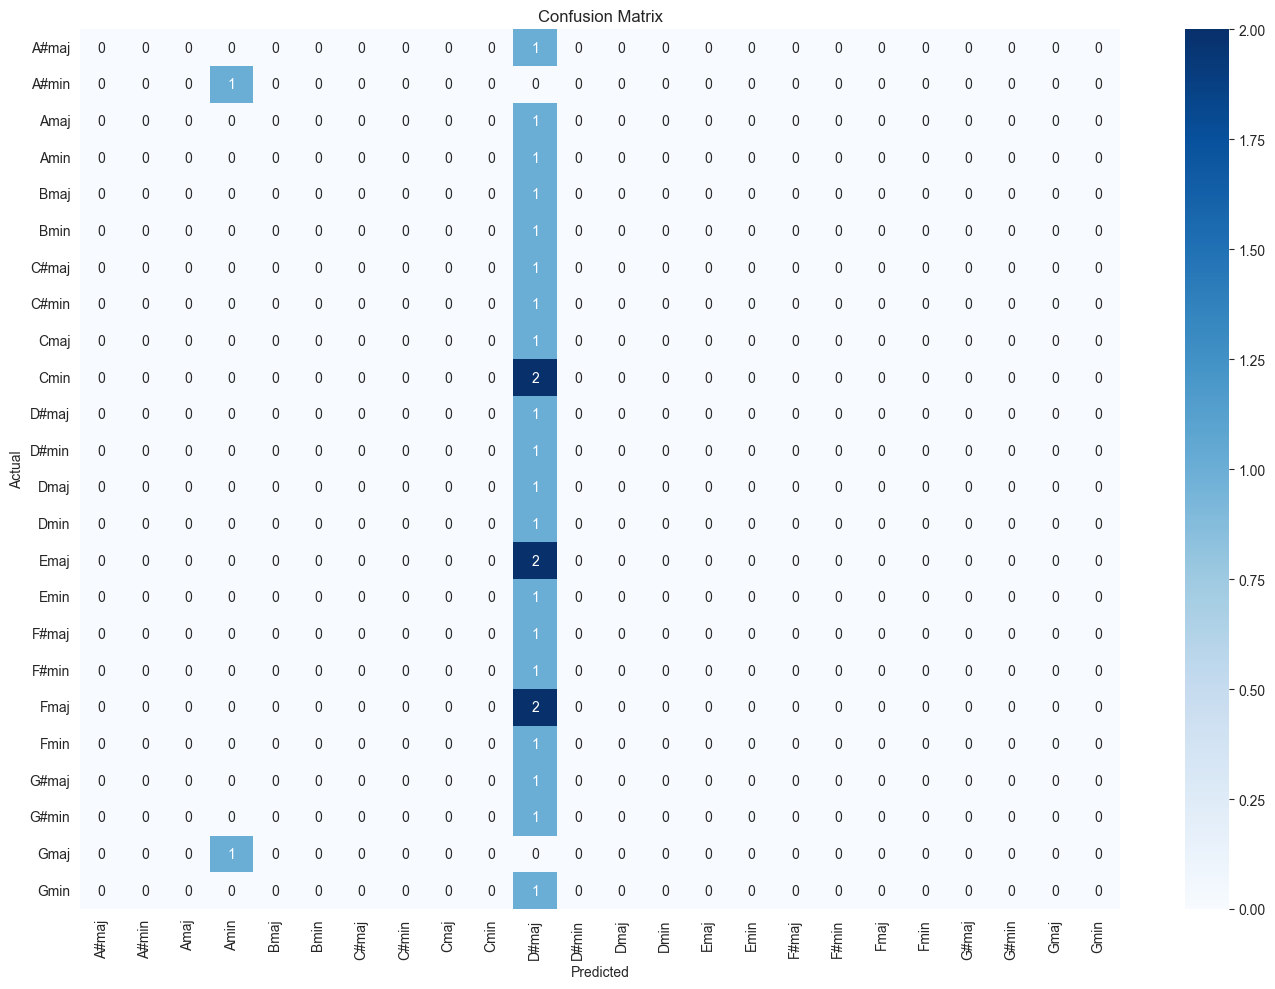

In [5]:
import numpy as np
import tensorflow as tf
import joblib
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Load files ---
base_path = r"C:\MelodicMind.AI\MEL & MODEL"

model = tf.keras.models.load_model(f"{base_path}\\mel_cnn_model.h5")
label_encoder = joblib.load(f"{base_path}\\label_encoder.pkl")

X = np.load(f"{base_path}\\mel_spectrograms.npy")
y_labels = np.load(f"{base_path}\\mel_labels.npy")

# Encode labels
y_encoded = label_encoder.transform(y_labels)
y_categorical = tf.keras.utils.to_categorical(y_encoded)

# Add channel dimension
X = X[..., np.newaxis]

# --- Step 2: Split (must match your training logic) ---
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.3, stratify=y_encoded, random_state=42
)

# --- Step 3: Predict and Evaluate ---
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Accuracy
accuracy = np.mean(y_pred == y_true)
print(f"🎯 Test Accuracy: {accuracy:.4f}")

# --- Step 4: Classification Report ---
print("\n🧾 Classification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# --- Step 5: Confusion Matrix ---
conf_mat = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 10))
sns.heatmap(conf_mat, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


DATA AUGMENTATION 
After Running This:
Each chord folder will now contain:

The original .wav file

5–6 augmented versions:

Pitch shifted

Time stretched

Noised

Louder

In [8]:
import os
import librosa
import soundfile as sf
import numpy as np

# --- Paths ---
SOURCE_PATH = r"C:\MelodicMind.AI\wav_chords"
AUGMENTED_PATH = r"C:\MelodicMind.AI\augmented_chords"
os.makedirs(AUGMENTED_PATH, exist_ok=True)

# --- Augmentation Functions ---
def pitch_shift_aug(y, sr, n_steps):
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

def time_stretch_aug(y, rate):
    return librosa.effects.time_stretch(y, rate=rate)

def add_noise_aug(y, noise_factor=0.005):
    noise = np.random.randn(len(y))
    return y + noise_factor * noise

def change_volume_aug(y, gain=1.2):
    return y * gain

# --- Processing & Saving ---
print("🎧 Starting data augmentation...")

for chord in os.listdir(SOURCE_PATH):
    chord_path = os.path.join(SOURCE_PATH, chord)
    if os.path.isdir(chord_path):
        save_chord_path = os.path.join(AUGMENTED_PATH, chord)
        os.makedirs(save_chord_path, exist_ok=True)

        for file in os.listdir(chord_path):
            if file.endswith(".wav"):
                file_path = os.path.join(chord_path, file)
                y, sr = librosa.load(file_path, sr=None)

                # Save original
                sf.write(os.path.join(save_chord_path, file), y, sr)

                # Augmentations
                sf.write(os.path.join(save_chord_path, f"{file[:-4]}_ps1.wav"), pitch_shift_aug(y, sr, 1), sr)
                sf.write(os.path.join(save_chord_path, f"{file[:-4]}_ps-1.wav"), pitch_shift_aug(y, sr, -1), sr)

                try:
                    stretched_up = time_stretch_aug(y, 1.05)
                    sf.write(os.path.join(save_chord_path, f"{file[:-4]}_ts1.wav"), stretched_up, sr)
                except Exception as e:
                    print(f"⚠️ Time stretch up failed on {file}: {e}")

                try:
                    stretched_down = time_stretch_aug(y, 0.95)
                    sf.write(os.path.join(save_chord_path, f"{file[:-4]}_ts2.wav"), stretched_down, sr)
                except Exception as e:
                    print(f"⚠️ Time stretch down failed on {file}: {e}")

                sf.write(os.path.join(save_chord_path, f"{file[:-4]}_noise.wav"), add_noise_aug(y), sr)
                sf.write(os.path.join(save_chord_path, f"{file[:-4]}_vol.wav"), change_volume_aug(y, 1.1), sr)

print("✅ Data Augmentation Complete! Augmented files saved in:")
print(AUGMENTED_PATH)



🎧 Starting data augmentation...
✅ Data Augmentation Complete! Augmented files saved in:
C:\MelodicMind.AI\augmented_chords


Next Step: Extract Mel Spectrograms & Train the CNN Again
We’ll:

Extract mel spectrograms from all the augmented .wav files.

Train a new 2D CNN model using the larger, diverse dataset.

Evaluate its performance (this should be much better than before!).

Full Updated Code: Mel Spectrogram Extraction + CNN Training
This will:

Load .wav files from C:\MelodicMind.AI\augmented_chords

Generate mel spectrograms

Train a 2D CNN

Save the model and encoder to C:\MelodicMind.AI\MEL & MODEL

In [11]:
import os
import librosa
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import joblib

# --- Step 1: Set Paths ---
DATASET_PATH = r"C:\MelodicMind.AI\augmented_chords"
SAVE_PATH = r"C:\MelodicMind.AI\MEL & MODEL"
os.makedirs(SAVE_PATH, exist_ok=True)

# --- Step 2: Extract mel spectrograms ---
def extract_mel_spectrogram(file_path, n_mels=128, duration=3, sr=22050):
    y, _ = librosa.load(file_path, sr=sr, duration=duration)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    S_DB = librosa.power_to_db(S, ref=np.max)
    return S_DB

X = []
y = []

print("🎧 Extracting Mel Spectrograms...")
for chord_label in os.listdir(DATASET_PATH):
    chord_path = os.path.join(DATASET_PATH, chord_label)
    if os.path.isdir(chord_path):
        for file in os.listdir(chord_path):
            if file.endswith(".wav"):
                file_path = os.path.join(chord_path, file)
                try:
                    mel_spec = extract_mel_spectrogram(file_path)
                    mel_spec = mel_spec[:, :128]  # Resize to fixed width
                    if mel_spec.shape[1] < 128:
                        continue
                    X.append(mel_spec)
                    y.append(chord_label)
                except Exception as e:
                    print(f"❌ Error with file {file_path}: {e}")

X = np.array(X)
y = np.array(y)
print(f"✅ Total Samples: {len(X)}")

# Save mel spectrograms and labels
np.save(os.path.join(SAVE_PATH, "mel_spectrograms.npy"), X)
np.save(os.path.join(SAVE_PATH, "mel_labels.npy"), y)

# --- Step 3: Encode labels ---
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# --- Step 4: Train/Test Split ---
X = X[..., np.newaxis]
min_test_samples = len(np.unique(y_encoded))
adjusted_test_size = max(0.3, min_test_samples / len(X))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=adjusted_test_size, stratify=y_encoded, random_state=42
)

# --- Step 5: CNN Model ---
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(X.shape[1], X.shape[2], 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# --- Step 6: Train ---
print("🚀 Training model...")
history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=8, callbacks=[early_stop], verbose=1)

# --- Step 7: Evaluate ---
loss, acc = model.evaluate(X_test, y_test)
print(f"\n🎯 Final Test Accuracy: {acc:.4f}")

# --- Step 8: Save model and encoder ---
model.save(os.path.join(SAVE_PATH, "mel_cnn_model.h5"))
joblib.dump(le, os.path.join(SAVE_PATH, "label_encoder.pkl"))

print("✅ Model and data saved in:", SAVE_PATH)


🎧 Extracting Mel Spectrograms...
✅ Total Samples: 630
🚀 Training model...
Epoch 1/50


C:\Users\User\PycharmProjects\pythonProject\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.0535 - loss: 19.3728 - val_accuracy: 0.0225 - val_loss: 3.1824
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.0829 - loss: 3.0327 - val_accuracy: 0.0899 - val_loss: 3.3337
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.0682 - loss: 3.1220 - val_accuracy: 0.0674 - val_loss: 3.0910
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.1060 - loss: 3.0741 - val_accuracy: 0.0562 - val_loss: 3.7443
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.0774 - loss: 3.1990 - val_accuracy: 0.0674 - val_loss: 3.1050
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.0739 - loss: 3.1253 - val_accuracy: 0.0449 - val_loss: 3.1600
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.0318 - loss: 3.2006 - val_accuracy: 0.0674 - val_loss: 3.0947
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.0558 - loss: 3.1049 - val_accuracy: 0.0674 - val_loss: 3


🎯 Final Test Accuracy: 0.0741
✅ Model and data saved in: C:\MelodicMind.AI\MEL & MODEL


Real-Time Chord Prediction from Microphone (Full Script)

FLASK....AND WEBSITE 

In [ ]:
from flask import Flask, render_template
import os
import csv

# Full paths
TEMPLATE_FOLDER = r"C:\MelodicMind.AI\WEBSITE\templates"
STATIC_FOLDER = r"C:\MelodicMind.AI\WEBSITE\static"
SONG_FOLDER = r"C:\MelodicMind.AI\WEBSITE\songs"
CSV_PATH = r"C:\MelodicMind.AI\WEBSITE\song info.csv"
ARTIST_IMG_PATH = "/static/artists/"

# Initialize Flask app
app = Flask(__name__, template_folder=TEMPLATE_FOLDER, static_folder=STATIC_FOLDER)

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/guitar')
def guitar():
    songs = []

    print("\n🔎 DEBUG START ---------------------")
    print(f"📁 Reading from CSV: {CSV_PATH}")
    print(f"📁 Looking for song files in: {SONG_FOLDER}")

    try:
        with open(CSV_PATH, newline='', encoding='utf-8-sig') as csvfile:
            raw = csv.reader(csvfile)
            headers = next(raw)
            headers = [h.strip().upper() for h in headers]
            reader = csv.DictReader(csvfile, fieldnames=headers)

            for row in reader:
                song = (row.get('SONG') or '').strip()
                artist = (row.get('ARTIST') or '').strip()
                year = (row.get('YEAR') or '').strip()

                print(f"📝 Row → SONG: '{song}' | ARTIST: '{artist}' | YEAR: '{year}'")

                if not song or not artist or not year:
                    print("⚠️ Skipping row (missing values)")
                    continue

                filename = song + ".txt"
                file_path = os.path.join(SONG_FOLDER, filename)

                print(f"🔍 Checking file: {file_path}")
                if not os.path.exists(file_path):
                    print(f"❌ File not found: {file_path}")
                    continue

                artist_img = artist.lower().replace(" ", "_") + ".jpg"

                songs.append({
                    'title': song.title(),
                    'artist': artist.title(),
                    'year': year,
                    'filename': filename,
                    'image': f"{ARTIST_IMG_PATH}{artist_img}"
                })

    except Exception as e:
        print(f"❗ ERROR reading CSV: {e}")

    print(f"✅ Total songs loaded: {len(songs)}")
    print("🔎 DEBUG END -----------------------\n")

    return render_template('guitar.html', songs=songs)



@app.route('/song/<song_name>')
def song_display(song_name):
    full_path = os.path.join(SONG_FOLDER, song_name)
    try:
        with open(full_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
    except FileNotFoundError:
        return f"❌ Song not found: {song_name}"
    return render_template('song_display.html', lines=lines, song_name=song_name)

@app.route('/karaoke')
def karaoke():
    return render_template('karaoke.html')

@app.route('/exit')
def shutdown():
    func = request.environ.get('werkzeug.server.shutdown')
    if func:
        func()
        return "🛑 Server shutting down..."
    return "❌ Could not shut down."

if __name__ == '__main__':
    app.run(debug=True, use_reloader=False)

In [ ]:
from flask import Flask, render_template
import os
import csv

# Full absolute paths
TEMPLATE_FOLDER = r"C:\MelodicMind.AI\WEBSITE\templates"
STATIC_FOLDER = r"C:\MelodicMind.AI\WEBSITE\static"
SONG_FOLDER = r"C:\MelodicMind.AI\WEBSITE\songs"
CSV_PATH = r"C:\MelodicMind.AI\WEBSITE\song info.csv"
ARTIST_IMG_PATH = "/static/artists/"

# Initialize Flask app
app = Flask(__name__, template_folder=TEMPLATE_FOLDER, static_folder=STATIC_FOLDER)

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/guitar')
def guitar():
    songs = []

    print("\n🔎 DEBUG START ---------------------")
    print(f"📁 Reading from CSV: {CSV_PATH}")
    print(f"📁 Looking for song files in: {SONG_FOLDER}")

    try:
        with open(CSV_PATH, newline='', encoding='utf-8-sig') as csvfile:
            raw = csv.reader(csvfile)
            headers = next(raw)
            headers = [h.strip().upper() for h in headers]
            reader = csv.DictReader(csvfile, fieldnames=headers)

            for row in reader:
                song = (row.get('SONG') or '').strip()
                artist = (row.get('ARTIST') or '').strip()
                year = (row.get('YEAR') or '').strip()

                print(f"📝 Row → SONG: '{song}' | ARTIST: '{artist}' | YEAR: '{year}'")

                if not song or not artist or not year:
                    print("⚠️ Skipping row (missing values)")
                    continue

                filename = song + ".txt"
                file_path = os.path.join(SONG_FOLDER, filename)

                print(f"🔍 Checking file: {file_path}")
                if not os.path.exists(file_path):
                    print(f"❌ File not found: {file_path}")
                    continue

                artist_img = artist.lower().replace(" ", "_") + ".jpg"

                songs.append({
                    'title': song.title(),
                    'artist': artist.title(),
                    'year': year,
                    'filename': filename,
                    'image': f"{ARTIST_IMG_PATH}{artist_img}"
                })

    except Exception as e:
        print(f"❗ ERROR reading CSV: {e}")

    print(f"✅ Total songs loaded: {len(songs)}")
    print("🔎 DEBUG END -----------------------\n")

    return render_template('guitar.html', songs=songs)

@app.route('/song/<song_name>')
def song_display(song_name):
    full_path = os.path.join(SONG_FOLDER, song_name)
    try:
        with open(full_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
    except FileNotFoundError:
        return f"❌ Song not found: {song_name}"
    return render_template('song_display.html', lines=lines, song_name=song_name)

@app.route('/karaoke')
def karaoke():
    try:
        karaoke_files = [f for f in os.listdir(SONG_FOLDER) if f.endswith('.txt')]
        return render_template('karaoke.html', songs=karaoke_files)
    except Exception as e:
        return f"❌ Could not load karaoke list: {e}"

@app.route('/karaoke/<song_name>')
def karaoke_display(song_name):
    full_path = os.path.join(SONG_FOLDER, song_name)
    try:
        with open(full_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
    except FileNotFoundError:
        return f"❌ Lyrics not found: {song_name}"
    return render_template('karaoke_display.html', lines=lines, song_name=song_name)

@app.route('/exit')
def shutdown():
    func = request.environ.get('werkzeug.server.shutdown')
    if func:
        func()
        return "🛑 Server shutting down..."
    return "❌ Could not shut down."

if __name__ == '__main__':
    app.run(debug=True, use_reloader=False)


In [ ]:
from flask import Flask, render_template
import os
import csv

# Absolute Paths
TEMPLATE_FOLDER = r"C:\MelodicMind.AI\WEBSITE\templates"
STATIC_FOLDER = r"C:\MelodicMind.AI\WEBSITE\static"
SONG_FOLDER = r"C:\MelodicMind.AI\WEBSITE\songs"
SONG_CSV_PATH = r"C:\MelodicMind.AI\WEBSITE\song info.csv"
KARAOKE_CSV = r"C:\MelodicMind.AI\WEBSITE\karaoke.csv"
ARTIST_IMG_PATH = "/static/artists/"

# Initialize Flask
app = Flask(__name__, template_folder=TEMPLATE_FOLDER, static_folder=STATIC_FOLDER)

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/guitar')
def guitar():
    songs = []
    try:
        with open(SONG_CSV_PATH, newline='', encoding='utf-8-sig') as csvfile:
            raw = csv.reader(csvfile)
            headers = next(raw)
            headers = [h.strip().upper() for h in headers]
            reader = csv.DictReader(csvfile, fieldnames=headers)

            for row in reader:
                song = (row.get('SONG') or '').strip()
                artist = (row.get('ARTIST') or '').strip()
                year = (row.get('YEAR') or '').strip()

                if not song or not artist or not year:
                    continue

                filename = song + ".txt"
                file_path = os.path.join(SONG_FOLDER, filename)
                artist_img = artist.lower().replace(" ", "_") + ".jpg"

                if not os.path.exists(file_path):
                    continue

                songs.append({
                    'title': song.title(),
                    'artist': artist.title(),
                    'year': year,
                    'filename': filename,
                    'image': f"{ARTIST_IMG_PATH}{artist_img}"
                })

    except Exception as e:
        print(f"⚠️ Error loading song CSV: {e}")

    return render_template('guitar.html', songs=songs)

@app.route('/song/<song_name>')
def song_display(song_name):
    full_path = os.path.join(SONG_FOLDER, song_name)
    try:
        with open(full_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
    except FileNotFoundError:
        return f"❌ Song not found: {song_name}"
    return render_template('song_display.html', lines=lines, song_name=song_name)

@app.route('/karaoke')
def karaoke():
    karaoke_files = []
    try:
        with open(KARAOKE_CSV, newline='', encoding='utf-8-sig') as csvfile:
            reader = csv.DictReader(csvfile)
            for row in reader:
                song = (row.get('SONG') or '').strip()
                if song:
                    karaoke_files.append(song)
    except Exception as e:
        return f"❌ Failed to load karaoke list: {e}"

    return render_template('karaoke.html', songs=karaoke_files)

@app.route('/karaoke/<song_name>')
def karaoke_display(song_name):
    youtube_url = None
    try:
        with open(KARAOKE_CSV, newline='', encoding='utf-8-sig') as csvfile:
            reader = csv.DictReader(csvfile)
            for row in reader:
                csv_song = row.get('SONG', '').strip().lower()
                match_song = song_name.replace('.txt', '').lower()

                if csv_song == match_song:
                    youtube_url = row.get('YOUTUBE_URL', '').strip()
                    break
    except Exception as e:
        return f"❌ Error loading karaoke video: {e}"

    if not youtube_url:
        return f"❌ No video found for: {song_name}"

    return render_template(
        'karaoke_video.html',
        song_name=song_name.replace('.txt', '').title(),
        youtube_url=youtube_url
    )

@app.route('/exit')
def shutdown():
    func = request.environ.get('werkzeug.server.shutdown')
    if func:
        func()
        return "🛑 Server shutting down..."
    return "❌ Could not shut down."

if __name__ == '__main__':
    app.run(debug=True, use_reloader=False)


 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [20/Apr/2025 02:23:43] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [20/Apr/2025 02:23:43] "GET /static/style.css HTTP/1.1" 304 -
127.0.0.1 - - [20/Apr/2025 02:23:45] "GET /karaoke HTTP/1.1" 200 -
127.0.0.1 - - [20/Apr/2025 02:23:45] "GET /static/style.css HTTP/1.1" 304 -
127.0.0.1 - - [20/Apr/2025 02:23:47] "GET /karaoke/channa%20mereya HTTP/1.1" 200 -
127.0.0.1 - - [20/Apr/2025 02:23:47] "GET /static/style.css HTTP/1.1" 304 -
127.0.0.1 - - [20/Apr/2025 02:24:05] "GET /karaoke/channa%20mereya HTTP/1.1" 200 -
127.0.0.1 - - [20/Apr/2025 02:24:05] "GET /static/style.css HTTP/1.1" 304 -


 Load the Model + Audio Listener in Flask
We'll use:

sounddevice or pyaudio for real-time audio capture

librosa for mel spectrogram conversion

tensorflow + joblib to use your trained model



Part 1: Backend – Real-Time Chord Listener via Flask /listen
🔧 What it Does:
Loads your trained model + label encoder

Listens via your mic using sounddevice

Converts audio to mel spectrogram

Predicts using mel_cnn_model.h5

After 2 chord sounds → returns { "scroll": true }



In [ ]:
from flask import Flask, render_template
import os
import csv

# Absolute Paths
TEMPLATE_FOLDER = r"C:\MelodicMind.AI\WEBSITE\templates"
STATIC_FOLDER = r"C:\MelodicMind.AI\WEBSITE\static"
SONG_FOLDER = r"C:\MelodicMind.AI\WEBSITE\songs"
SONG_CSV_PATH = r"C:\MelodicMind.AI\WEBSITE\song info.csv"
KARAOKE_CSV = r"C:\MelodicMind.AI\WEBSITE\karaoke.csv"
ARTIST_IMG_PATH = "/static/artists/"

# Initialize Flask
app = Flask(__name__, template_folder=TEMPLATE_FOLDER, static_folder=STATIC_FOLDER)

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/guitar')
def guitar():
    songs = []
    try:
        with open(SONG_CSV_PATH, newline='', encoding='utf-8-sig') as csvfile:
            raw = csv.reader(csvfile)
            headers = next(raw)
            headers = [h.strip().upper() for h in headers]
            reader = csv.DictReader(csvfile, fieldnames=headers)

            for row in reader:
                song = (row.get('SONG') or '').strip()
                artist = (row.get('ARTIST') or '').strip()
                year = (row.get('YEAR') or '').strip()

                if not song or not artist or not year:
                    continue

                filename = song + ".txt"
                file_path = os.path.join(SONG_FOLDER, filename)
                artist_img = artist.lower().replace(" ", "_") + ".jpg"

                if not os.path.exists(file_path):
                    continue

                songs.append({
                    'title': song.title(),
                    'artist': artist.title(),
                    'year': year,
                    'filename': filename,
                    'image': f"{ARTIST_IMG_PATH}{artist_img}"
                })

    except Exception as e:
        print(f"⚠️ Error loading song CSV: {e}")

    return render_template('guitar.html', songs=songs)

@app.route('/song/<song_name>')
def song_display(song_name):
    full_path = os.path.join(SONG_FOLDER, song_name)
    try:
        with open(full_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
    except FileNotFoundError:
        return f"❌ Song not found: {song_name}"
    return render_template('song_display.html', lines=lines, song_name=song_name)

@app.route('/karaoke')
def karaoke():
    karaoke_files = []
    try:
        with open(KARAOKE_CSV, newline='', encoding='utf-8-sig') as csvfile:
            reader = csv.DictReader(csvfile)
            for row in reader:
                song = (row.get('SONG') or '').strip()
                if song:
                    karaoke_files.append(song)
    except Exception as e:
        return f"❌ Failed to load karaoke list: {e}"

    return render_template('karaoke.html', songs=karaoke_files)

@app.route('/karaoke/<song_name>')
def karaoke_display(song_name):
    youtube_url = None
    try:
        with open(KARAOKE_CSV, newline='', encoding='utf-8-sig') as csvfile:
            reader = csv.DictReader(csvfile)
            for row in reader:
                csv_song = row.get('SONG', '').strip().lower()
                match_song = song_name.replace('.txt', '').lower()

                if csv_song == match_song:
                    youtube_url = row.get('YOUTUBE_URL', '').strip()
                    if "watch?v=" in youtube_url:
                        youtube_url = youtube_url.replace("watch?v=", "embed/")
                    break
    except Exception as e:
        return f"❌ Error loading karaoke video: {e}"

    if not youtube_url:
        return f"❌ No video found for: {song_name}"

    return render_template(
        'karaoke_video.html',
        song_name=song_name.replace('.txt', '').title(),
        youtube_url=youtube_url
    )

@app.route('/exit')
def shutdown():
    func = request.environ.get('werkzeug.server.shutdown')
    if func:
        func()
        return "🛑 Server shutting down..."
    return "❌ Could not shut down."

# -------------------------
# 🎸 Chord Detection Section
# -------------------------
import sounddevice as sd
import librosa
import numpy as np
import joblib
import tensorflow as tf

MODEL_PATH = r"C:\MelodicMind.AI\MEL & MODEL\mel_cnn_model.h5"
ENCODER_PATH = r"C:\MelodicMind.AI\MEL & MODEL\label_encoder.pkl"

scroll_trigger_count = 0  # counter for valid chord predictions

try:
    model = tf.keras.models.load_model(MODEL_PATH)
    encoder = joblib.load(ENCODER_PATH)
    print("✅ Model and encoder loaded successfully.")
except Exception as e:
    print(f"❌ Failed to load model or encoder: {e}")
    model = None
    encoder = None

def detect_chord_from_audio(duration=1.0, sr=22050):
    if model is None or encoder is None:
        print("❌ Model not loaded.")
        return False

    try:
        print("🎧 Listening for chord...")
        recording = sd.rec(int(duration * sr), samplerate=sr, channels=1, dtype='float32')
        sd.wait()

        y = np.squeeze(recording)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_db = librosa.power_to_db(mel_spec, ref=np.max)

        mel_db = mel_db[:, :128]
        if mel_db.shape[1] < 128:
            mel_db = np.pad(mel_db, ((0, 0), (0, 128 - mel_db.shape[1])), mode='constant')

        X = mel_db[np.newaxis, ..., np.newaxis]
        prediction = model.predict(X, verbose=0)
        predicted_index = np.argmax(prediction)
        predicted_label = encoder.inverse_transform([predicted_index])[0]
        confidence = np.max(prediction)

        print(f"🎯 Detected chord: {predicted_label} | Confidence: {confidence:.2f}")
        return confidence > 0.5
    except Exception as e:
        print(f"❌ Detection error: {e}")
        return False

@app.route('/listen')
def listen():
    global scroll_trigger_count
    chord_detected = detect_chord_from_audio()

    if chord_detected:
        scroll_trigger_count += 1
        print(f"📈 Scroll counter: {scroll_trigger_count}/2")
        if scroll_trigger_count >= 2:
            scroll_trigger_count = 0
            return { "scroll": True }

    return { "scroll": False }

# -------------------------
# END
# -------------------------

if __name__ == '__main__':
    app.run(debug=True, use_reloader=False)
    
    


INFO:werkzeug:127.0.0.1 - - [21/Apr/2025 00:48:00] "GET /guitar HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Apr/2025 00:48:01] "GET /static/style.css HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [21/Apr/2025 00:48:01] "GET /static/artists/ed_sheeran.jpg HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [21/Apr/2025 00:48:01] "GET /static/artists/lata_mangeshkar.jpg HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [21/Apr/2025 00:48:01] "GET /static/artists/arijit_singh.jpg HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [21/Apr/2025 00:48:01] "GET /static/artists/vishal_mishra.jpg HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [21/Apr/2025 00:48:01] "GET /static/artists/lord_huron.jpg HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [21/Apr/2025 00:48:01] "GET /static/artists/atif_aslam.jpg HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [21/Apr/2025 00:48:08] "GET /song/phir%20mohabbat.txt HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [21/Apr/2025 00:48:08] "GET /static/style.css HTTP/1.1" 304 -


🎧 Listening for chord...


INFO:werkzeug:127.0.0.1 - - [21/Apr/2025 00:48:21] "GET /listen HTTP/1.1" 200 -


🎯 Detected chord: Gmaj | Confidence: 0.88
📈 Scroll counter: 2/2
🎧 Listening for chord...


INFO:werkzeug:127.0.0.1 - - [21/Apr/2025 00:48:23] "GET /listen HTTP/1.1" 200 -


...

🎯 Detected chord: A#min | Confidence: 0.81
📈 Scroll counter: 1/2
🎧 Listening for chord...


INFO:werkzeug:127.0.0.1 - - [21/Apr/2025 00:54:37] "GET /listen HTTP/1.1" 200 -


🎯 Detected chord: A#maj | Confidence: 0.31
🎧 Listening for chord...


INFO:werkzeug:127.0.0.1 - - [21/Apr/2025 00:54:40] "GET /listen HTTP/1.1" 200 -


🎯 Detected chord: Gmaj | Confidence: 0.85
📈 Scroll counter: 2/2
🎧 Listening for chord...
